In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
import os

# 1. 데이터 로드 및 전처리
df_sdl = pd.read_csv('./sdl/simulated_sdl_data.csv')

# SDL 사전 검사 문항들(Q1~Q15)의 평균 계산
pre_cols = [c for c in df_sdl.columns if c.startswith('SDL_Pre_')]
df_sdl['SDL_Pre_Mean'] = df_sdl[pre_cols].mean(axis=1)

# 집단 분리
exp_group = df_sdl[df_sdl['Group'] == 'Experimental']['SDL_Pre_Mean'].values
ctrl_group = df_sdl[df_sdl['Group'] == 'Control']['SDL_Pre_Mean'].values

print(f"📊 [기술통계] 실험집단 평균: {np.mean(exp_group):.3f}, 통제집단 평균: {np.mean(ctrl_group):.3f}")

/home/atruergod/python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📊 [기술통계] 실험집단 평균: 5.159, 통제집단 평균: 5.233


In [2]:
# ==========================================
# 2. 고전 통계학 기반 t-검정 (Frequentist)
# ==========================================
t_stat, p_val = stats.ttest_ind(exp_group, ctrl_group, equal_var=True)
is_homogeneous = p_val >= 0.05

print("\n--- [고전 통계학: 독립표본 t-검정 결과] ---")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value : {p_val:.4f}")
print(f"결론: {'동질성 확보 (귀무가설 채택)' if is_homogeneous else '집단 간 차이 존재'}")


--- [고전 통계학: 독립표본 t-검정 결과] ---
t-통계량: -0.2676
p-value : 0.7906
결론: 동질성 확보 (귀무가설 채택)


In [3]:
# ==========================================
# 3. 베이지안 통계학 기반 t-검정 (Bayesian)
# ==========================================
# 1번 파일의 Stan 모델 구조 반영
stan_code = """
data {
    int<lower=0> n1;
    int<lower=0> n2;
    vector[n1] y1;
    vector[n2] y2;
}
parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;
}
model {
    mu1 ~ normal(0, 10);
    mu2 ~ normal(0, 10);
    sigma ~ exponential(0.1);
    y1 ~ normal(mu1, sigma);
    y2 ~ normal(mu2, sigma);
}
generated quantities {
    real delta = mu1 - mu2;
}
"""

# 임시 파일에 Stan 코드 저장 및 컴파일
with open("sdl_homogeneity.stan", "w") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file="sdl_homogeneity.stan")

# 데이터 준비 및 MCMC 샘플링
stan_data = {
    'n1': len(exp_group),
    'n2': len(ctrl_group),
    'y1': exp_group,
    'y2': ctrl_group
}

fit = model.sample(data=stan_data, iter_sampling=2000, iter_warmup=1000, chains=4, seed=42)

# 결과 추출
delta_samples = fit.stan_variable('delta')
mu1_samples = fit.stan_variable('mu1')
mu2_samples = fit.stan_variable('mu2')

ci_lo, ci_hi = np.percentile(delta_samples, [2.5, 97.5])
post_mean = np.mean(delta_samples)
contains_zero = ci_lo <= 0 <= ci_hi

print("\n--- [베이지안 통계학: 사후분포 분석 결과] ---")
print(f"평균 차이(delta)의 사후 평균: {post_mean:.4f}")
print(f"95% 신용구간 (Credible Interval): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"0 포함 여부: {'예 (동질적)' if contains_zero else '아니오 (이질적)'}")

15:53:26 - cmdstanpy - INFO - compiling stan file /home/atruergod/python/26-1/simulations/pbl/sdl_homogeneity.stan to exe file /home/atruergod/python/26-1/simulations/pbl/sdl_homogeneity
15:53:45 - cmdstanpy - INFO - compiled model executable: /home/atruergod/python/26-1/simulations/pbl/sdl_homogeneity
15:53:45 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]


chain 1:  33%|███▎      | 1000/3000 [00:00<00:00, 20447.35it/s, (Sampling)]


chain 2: 100%|██████████| 3000/3000 [00:00<00:00, 27570.34it/s, (Sampling completed)]


chain 3: 100%|██████████| 3000/3000 [00:00<00:00, 26456.25it/s, (Sampling completed)]




chain 4: 100%|██████████| 3000/3000 [00:00<00:00, 25959.24it/s, (Sampling completed)]


15:53:46 - cmdstanpy - INFO - CmdStan done processing.




--- [베이지안 통계학: 사후분포 분석 결과] ---
평균 차이(delta)의 사후 평균: -0.0835
95% 신용구간 (Credible Interval): [-0.6538, 0.4727]
0 포함 여부: 예 (동질적)


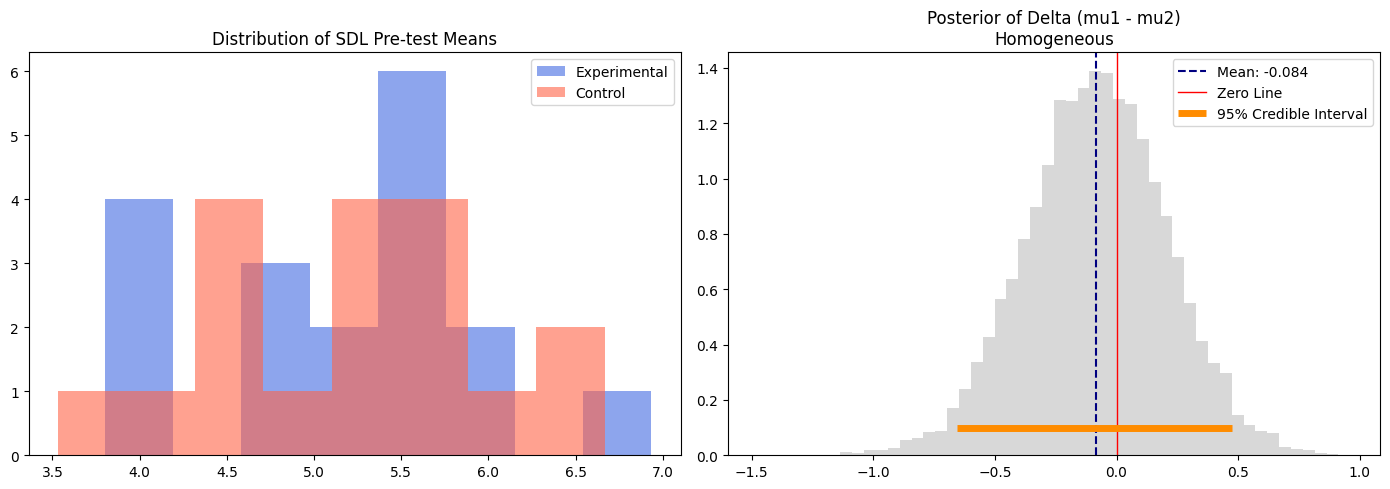

In [4]:
# ==========================================
# 4. 시각화 (1번 파일 스타일)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: 사전 점수 분포 (Histogram)
axes[0].hist(exp_group, alpha=0.6, label='Experimental', color='royalblue', bins=8)
axes[0].hist(ctrl_group, alpha=0.6, label='Control', color='tomato', bins=8)
axes[0].set_title("Distribution of SDL Pre-test Means")
axes[0].legend()

# Panel 2: 평균 차이(delta)의 사후분포
axes[1].hist(delta_samples, bins=50, density=True, color='gray', alpha=0.3)
axes[1].axvline(post_mean, color='navy', linestyle='--', label=f'Mean: {post_mean:.3f}')
axes[1].axvline(0, color='red', linewidth=1, label='Zero Line')
axes[1].hlines(y=0.1, xmin=ci_lo, xmax=ci_hi, color='darkorange', linewidth=5, label='95% Credible Interval')
axes[1].set_title(f"Posterior of Delta (mu1 - mu2)\n{'Homogeneous' if contains_zero else 'Not Homogeneous'}")
axes[1].legend()

plt.tight_layout()
plt.show()